In [1]:
import pandas as pd

In [4]:
df=pd.read_csv("house_price_regression_dataset.csv")

In [5]:
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


In [7]:
df.isnull().sum()

Square_Footage          0
Num_Bedrooms            0
Num_Bathrooms           0
Year_Built              0
Lot_Size                0
Garage_Size             0
Neighborhood_Quality    0
House_Price             0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [12]:
Q1=df.quantile(0.25)
Q3=df.quantile(0.75)
IQR=Q3-Q1
df_clean=df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 +1.5 *IQR))).any(axis=1)]
print("Before:", df.shape)
print("After:", df_clean.shape)

Before: (1000, 8)
After: (1000, 8)


In [13]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
df_minmax=scaler.fit_transform(df_clean)

In [14]:
import pandas as pd
df_minmax= pd.DataFrame(df_minmax, columns=df_clean.columns)
df_minmax.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,0.190614,0.25,0.0,0.430556,0.020873,0.0,0.444444,0.151269
1,0.838301,0.50,1.0,0.916667,0.947295,0.5,0.555556,0.876606
2,0.687055,0.00,0.5,0.916667,0.697880,0.0,0.888889,0.668617
3,0.102980,0.00,0.5,0.375000,0.496205,0.5,0.777778,0.118474
4,0.983763,0.25,0.0,0.597222,0.935263,0.0,0.777778,0.933278


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_zscore = scaler.fit_transform(df_clean)

In [16]:
import pandas as pd

df_zscore = pd.DataFrame(df_zscore, columns=df_clean.columns)
df_zscore.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,-1.159803,-0.693836,-1.186699,-0.269122,-1.679278,-1.254658,-0.213126,-1.406552
1,1.160724,0.007008,1.252559,1.428045,1.522390,-0.027008,0.133420,1.445699
2,0.618843,-1.394681,0.032930,1.428045,0.660422,-1.254658,1.173060,0.627824
3,-1.473776,-1.394681,0.032930,-0.463084,-0.036555,-0.027008,0.826514,-1.535512
4,1.681887,-0.693836,-1.186699,0.312764,1.480809,-1.254658,0.826514,1.668552


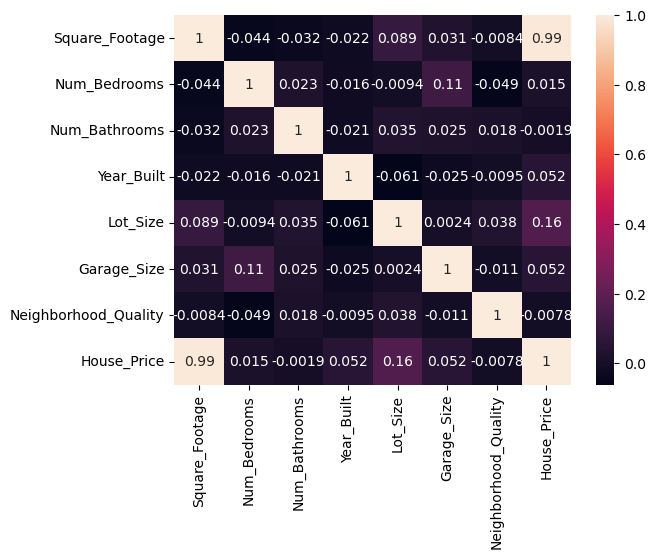

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df_clean.corr()

sns.heatmap(corr, annot=True)
plt.show()

In [18]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(df_clean)

print("Explained Variance:", pca.explained_variance_ratio_)

Explained Variance: [9.99999567e-01 4.28695218e-07]
